In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from plotly.subplots import make_subplots
import polars as pl
import polars.selectors as cs
import plotly.graph_objects as go
import plotly.express as px
import polars.selectors as cs
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import duckdb

from preprocess import load_ts_data, preprocess_pipeline

In [2]:
data_path = Path("./data")

In [3]:
# Datos tabulares
train_demographics_lf = pl.scan_csv(
    data_path / "train_demographics.csv", infer_schema=True
)
test_demographics_lf = pl.scan_csv(
    data_path / "test_demographics.csv", infer_schema=True
)

display(train_demographics_lf.head(5).collect())
display(test_demographics_lf.head(5).collect())

subject,adult_child,age,sex,handedness,height_cm,shoulder_to_wrist_cm,elbow_to_wrist_cm
str,i64,i64,i64,i64,f64,i64,f64
"""SUBJ_000206""",1,41,1,1,172.0,50,25.0
"""SUBJ_001430""",0,11,0,1,167.0,51,27.0
"""SUBJ_002923""",1,28,1,0,164.0,54,26.0
"""SUBJ_003328""",1,33,1,1,171.0,52,25.0
"""SUBJ_004117""",0,15,0,1,184.0,54,28.0


subject,adult_child,age,sex,handedness,height_cm,shoulder_to_wrist_cm,elbow_to_wrist_cm
str,i64,i64,i64,i64,f64,i64,f64
"""SUBJ_016452""",1,25,1,1,165.0,52,23.0
"""SUBJ_055840""",0,13,0,1,177.0,52,27.0


In [4]:
# Datos de series temporales
# train_lf = pl.scan_csv(data_path / "train.csv", infer_schema=True, null_values="-1.0")
# train_lf = (
#     train_lf.sort(["sequence_id", "sequence_counter"])
#     .drop(pl.col("row_id"))
#     .with_columns(
#         pl.col(pl.Float64).cast(pl.Float32),
#         pl.col(
#             [
#                 "sequence_type",
#                 "sequence_id",
#                 "subject",
#                 "orientation",
#                 "phase",
#                 "gesture",
#             ]
#         ).cast(pl.Categorical),
#     )
# )
# test_lf = pl.scan_csv(data_path / "test.csv", infer_schema=True)

train_lf: pl.LazyFrame = load_ts_data(data_path / "train.csv", null_values="-1.0")
test_lf: pl.LazyFrame = load_ts_data(data_path / "test.csv", null_values="-1.0")

display(train_lf.head(5).collect())
train_lf.collect_schema()

sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,acc_y,acc_z,rot_w,rot_x,rot_y,rot_z,thm_1,thm_2,thm_3,thm_4,thm_5,tof_1_v0,tof_1_v1,tof_1_v2,tof_1_v3,tof_1_v4,tof_1_v5,tof_1_v6,tof_1_v7,tof_1_v8,tof_1_v9,tof_1_v10,tof_1_v11,tof_1_v12,tof_1_v13,tof_1_v14,tof_1_v15,tof_1_v16,…,tof_5_v27,tof_5_v28,tof_5_v29,tof_5_v30,tof_5_v31,tof_5_v32,tof_5_v33,tof_5_v34,tof_5_v35,tof_5_v36,tof_5_v37,tof_5_v38,tof_5_v39,tof_5_v40,tof_5_v41,tof_5_v42,tof_5_v43,tof_5_v44,tof_5_v45,tof_5_v46,tof_5_v47,tof_5_v48,tof_5_v49,tof_5_v50,tof_5_v51,tof_5_v52,tof_5_v53,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
cat,cat,i64,cat,cat,str,cat,cat,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""Target""","""SEQ_000007""",0,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",6.683594,6.214844,3.355469,0.134399,-0.355164,-0.447327,-0.809753,28.943842,31.822186,29.553024,28.592863,28.310535,131.0,134.0,132.0,135.0,98.0,74.0,64.0,60.0,null,null,152.0,153.0,141.0,89.0,68.0,63.0,null,…,153.0,133.0,131.0,121.0,118.0,134.0,134.0,128.0,121.0,119.0,121.0,129.0,null,113.0,124.0,122.0,131.0,null,null,null,null,120.0,127.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Target""","""SEQ_000007""",1,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",6.949219,6.214844,3.125,0.143494,-0.340271,-0.42865,-0.824524,29.340816,31.874645,29.79174,28.663383,28.406172,130.0,138.0,131.0,135.0,101.0,76.0,66.0,61.0,null,null,156.0,155.0,141.0,93.0,74.0,64.0,null,…,157.0,139.0,127.0,126.0,121.0,136.0,142.0,133.0,127.0,123.0,127.0,134.0,null,116.0,122.0,123.0,126.0,null,null,null,null,122.0,129.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Target""","""SEQ_000007""",2,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",5.722656,5.410156,5.421875,0.219055,-0.274231,-0.356934,-0.865662,30.339359,30.935045,30.090014,28.796087,28.529778,137.0,136.0,147.0,109.0,90.0,81.0,74.0,74.0,null,164.0,165.0,146.0,106.0,94.0,77.0,77.0,null,…,null,null,151.0,138.0,127.0,151.0,187.0,null,156.0,136.0,135.0,134.0,null,133.0,142.0,131.0,130.0,132.0,136.0,null,null,112.0,121.0,123.0,125.0,null,null,null,null,112.0,119.0,null,null,null,null,null,null
"""Target""","""SEQ_000007""",3,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",6.6015625,3.53125,6.457031,0.297546,-0.26416,-0.238159,-0.885986,30.54373,27.044001,29.310717,29.018711,27.40201,143.0,147.0,170.0,127.0,109.0,98.0,95.0,95.0,null,177.0,189.0,177.0,136.0,121.0,107.0,104.0,null,…,null,149.0,142.0,135.0,null,159.0,181.0,150.0,135.0,129.0,139.0,null,null,141.0,136.0,120.0,122.0,132.0,null,null,null,107.0,112.0,115.0,140.0,null,null,null,null,101.0,111.0,null,null,null,null,null,null
"""Target""","""SEQ_000007""",4,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",5.566406,0.277344,9.6328125,0.333557,-0.218628,-0.063538,-0.914856,29.317265,25.270855,26.808746,29.408604,27.357603,178.0,191.0,183.0,157.0,146.0,139.0,143.0,148.0,null,null,236.0,238.0,208.0,200.0,185.0,190.0,null,…,212.0,181.0,null,null,null,184.0,null,179.0,162.0,null,null,null,null,169.0,171.0,145.0,140.0,null,null,null,null,132.0,125.0,131.0,null,null,null,null,null,101.0,109.0,125.0,null,null,null,null,null


Schema([('sequence_type', Categorical),
        ('sequence_id', Categorical),
        ('sequence_counter', Int64),
        ('subject', Categorical),
        ('orientation', Categorical),
        ('behavior', String),
        ('phase', Categorical),
        ('gesture', Categorical),
        ('acc_x', Float32),
        ('acc_y', Float32),
        ('acc_z', Float32),
        ('rot_w', Float32),
        ('rot_x', Float32),
        ('rot_y', Float32),
        ('rot_z', Float32),
        ('thm_1', Float32),
        ('thm_2', Float32),
        ('thm_3', Float32),
        ('thm_4', Float32),
        ('thm_5', Float32),
        ('tof_1_v0', Float32),
        ('tof_1_v1', Float32),
        ('tof_1_v2', Float32),
        ('tof_1_v3', Float32),
        ('tof_1_v4', Float32),
        ('tof_1_v5', Float32),
        ('tof_1_v6', Float32),
        ('tof_1_v7', Float32),
        ('tof_1_v8', Float32),
        ('tof_1_v9', Float32),
        ('tof_1_v10', Float32),
        ('tof_1_v11', Float32),
       

In [5]:
# def group_tof_sensors(lf: pl.LazyFrame) -> pl.LazyFrame:
#     for i in range(1, 6):
#         tof_cols = [f"tof_{i}_v{j}" for j in range(64)]
#         lf = lf.with_columns(pl.concat_arr(tof_cols).alias(f"tof_{i}"))
#     return lf.drop(pl.selectors.matches(r"^tof_\d_v\d+$"))


# train_lf = group_tof_sensors(train_lf)
# display(train_lf.head(5).collect())
# train_lf.collect_schema()

In [6]:
print(
    f"There are {train_lf.select(pl.col('sequence_id').n_unique()).collect()[0, 0]} unique sequences in the training set."
)
print(
    f"There are {train_lf.select(pl.col('subject').n_unique()).collect()[0, 0]} unique subjects in the training set."
)

There are 8151 unique sequences in the training set.
There are 81 unique subjects in the training set.


In [7]:
print("All gestures in the training set:")
for gesture in train_lf.select("gesture").unique().collect().to_series():
    print(f" > {gesture}")

All gestures in the training set:
 > Forehead - pull hairline
 > Eyebrow - pull hair
 > Neck - scratch
 > Drink from bottle/cup
 > Pull air toward your face
 > Wave hello
 > Pinch knee/leg skin
 > Write name in air
 > Write name on leg
 > Forehead - scratch
 > Neck - pinch skin
 > Cheek - pinch skin
 > Glasses on/off
 > Feel around in tray and pull out an object
 > Eyelash - pull hair
 > Above ear - pull hair
 > Text on phone
 > Scratch knee/leg skin


In [8]:
train_df = train_lf.pipe(preprocess_pipeline)

print(f"Shape: {train_df.shape}")
print(
    f"Nulos restantes en columnas Float32: "
    f"{train_df.select(cs.float()).null_count().sum_horizontal()[0]}"
)
display(train_df.head(5))

Shape: (574945, 40)
Nulos restantes en columnas Float32: 90070


sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,acc_y,acc_z,rot_w,rot_x,rot_y,rot_z,thm_1,thm_2,thm_3,thm_4,thm_5,tof_1,tof_2,tof_3,tof_4,tof_5,acc_x_diff,acc_y_diff,acc_z_diff,rot_w_diff,rot_x_diff,rot_y_diff,rot_z_diff,acc_x_rmean5,acc_y_rmean5,acc_z_rmean5,rot_w_rmean5,rot_x_rmean5,rot_y_rmean5,rot_z_rmean5,acc_magnitude
cat,cat,i64,cat,cat,str,cat,cat,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,"array[f32, 64]","array[f32, 64]","array[f32, 64]","array[f32, 64]","array[f32, 64]",f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""Target""","""SEQ_000007""",0,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",0.604945,0.995991,0.516518,-1.253975,-0.419001,-0.703799,-1.21285,0.734661,1.913637,1.162349,0.759733,0.891703,"[131.0, 134.0, … 118.0]","[96.0, null, … 85.0]","[58.0, 55.0, … 100.0]","[null, null, … 60.0]","[128.0, 130.0, … null]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.604945,0.995991,0.516518,-1.253975,-0.419001,-0.703799,-1.21285,1.274655
"""Target""","""SEQ_000007""",1,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",0.652261,0.995991,0.476626,-1.213572,-0.37923,-0.670061,-1.242996,0.918895,1.934746,1.271637,0.805136,0.942932,"[130.0, 138.0, … 117.0]","[109.0, null, … 95.0]","[75.0, 67.0, … 105.0]","[134.0, null, … 74.0]","[126.0, 137.0, … null]",0.047316,0.0,-0.039892,0.040403,0.039771,0.033738,-0.030146,0.628603,0.995991,0.496572,-1.233774,-0.399116,-0.68693,-1.227923,1.282425
"""Target""","""SEQ_000007""",2,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",0.433772,0.825338,0.874194,-0.877875,-0.20287,-0.540511,-1.326955,1.382313,1.556664,1.408192,0.890574,1.009143,"[137.0, 136.0, … 120.0]","[119.0, null, … null]","[73.0, 94.0, … 118.0]","[139.0, 149.0, … 105.0]","[92.0, 110.0, … null]",-0.21849,-0.170653,0.397568,0.335697,0.176361,0.12955,-0.08396,0.563659,0.939106,0.622446,-1.115141,-0.3337,-0.638124,-1.260934,1.278106
"""Target""","""SEQ_000007""",3,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",0.590333,0.426872,1.05337,-0.529162,-0.175976,-0.325954,-1.368437,1.47716,-0.009042,1.051416,1.033905,0.40504,"[143.0, 147.0, … 124.0]","[108.0, 123.0, … null]","[119.0, 132.0, … null]","[139.0, 146.0, … 175.0]","[105.0, 132.0, … null]",0.156561,-0.398466,0.179176,0.348713,0.026894,0.214557,-0.041481,0.570328,0.811048,0.730177,-0.968646,-0.294269,-0.560082,-1.287809,1.280743
"""Target""","""SEQ_000007""",4,"""SUBJ_059520""","""Seated Lean Non Dom - FACE DOW…","""Relaxes and moves hand to targ…","""Transition""","""Cheek - pinch skin""",0.405939,-0.263194,1.603069,-0.369177,-0.054381,-0.010514,-1.427358,0.907965,-0.722532,-0.094033,1.284928,0.381253,"[178.0, 191.0, … null]","[138.0, 155.0, … null]","[null, null, … null]","[139.0, 138.0, … null]","[127.0, 185.0, … null]",-0.184394,-0.690066,0.549699,0.159985,0.121594,0.31544,-0.058921,0.53745,0.5962,0.904755,-0.848752,-0.246292,-0.450168,-1.315719,1.674481


---

In [9]:
def gesture_palette(gestures: list[str]) -> dict:
    """Genera un diccionario que asigna un color distinto a cada gesto.

    :param gestures: Lista de nombres de gestos únicos.
    :return: Diccionario con la asignación de colores por gesto.
    """
    colors = px.colors.qualitative.Vivid
    return {g: colors[i % len(colors)] for i, g in enumerate(sorted(gestures))}

In [10]:
def plot_subject_imu(df: pl.DataFrame, subject_id: str, max_rows: int = 3000):
    """Muestra acc_x/y/z y rot_w/x/y/z de un sujeto concreto. El fondo se colorea según el gesto activo en cada timestep.
    Esto permite visualizar cómo varían las señales IMU con cada gesto, y si hay patrones característicos para cada gesto.
    Es útil para entender la relación entre las señales IMU y los gestos, y si hay diferencias claras entre ellos.

    :param df: DataFrame con los datos de entrenamiento, incluyendo las columnas `subject`, `gesture`, `sequence_id`, `sequence_counter` y las señales IMU.
    :param subject_id: ID del sujeto a visualizar (ej. "SUBJ_059520").
    :param max_rows: número máximo de filas a mostrar (para evitar sobrecargar la visualización), por defecto a 3000.
    :return: Figura de Plotly con las señales IMU del sujeto, coloreadas por gesto.
    """
    sub = (
        df.filter(pl.col("subject") == subject_id)
        .sort(["sequence_id", "sequence_counter"])
        .head(max_rows)
        .to_pandas()
    )

    imu_signals = [
        "acc_x",
        "acc_y",
        "acc_z",
        "acc_magnitude",
        "rot_w",
        "rot_x",
        "rot_y",
        "rot_z",
    ]
    imu_signals = [c for c in imu_signals if c in sub.columns]

    gestures = sub["gesture"].unique().tolist()
    palette = gesture_palette(gestures)
    sub["t"] = range(len(sub))

    fig = make_subplots(
        rows=len(imu_signals),
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.02,
        subplot_titles=imu_signals,
    )

    # Bandas de fondo por gesto
    for _, seg in sub.groupby((sub["gesture"] != sub["gesture"].shift()).cumsum()):
        g = seg["gesture"].iloc[0]
        x0, x1 = seg["t"].iloc[0], seg["t"].iloc[-1]
        color = palette.get(g, "#cccccc")
        for row in range(1, len(imu_signals) + 1):
            fig.add_vrect(
                x0=x0,
                x1=x1,
                fillcolor=color,
                opacity=0.15,
                line_width=0,
                row=row,
                col=1,
            )

    # Señales
    for row, col in enumerate(imu_signals, start=1):
        fig.add_trace(
            go.Scatter(
                x=sub["t"],
                y=sub[col],
                mode="lines",
                line=dict(width=0.8, color="#2c3e50"),
                name=col,
                showlegend=False,
            ),
            row=row,
            col=1,
        )

    # Leyenda de gestos
    for g, c in palette.items():
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="markers",
                marker=dict(size=10, color=c),
                name=g,
                legendgroup=g,
            )
        )

    fig.update_layout(
        title=f"Sujeto {subject_id} - señales IMU del gesto {sub['gesture'].iloc[0]}",
        height=150 * len(imu_signals) + 80,
        template="plotly_white",
        legend=dict(orientation="h", y=-0.05),
    )
    return fig


subject_to_show = train_df.select("subject").sample().to_numpy()[0, 0]
plot_subject_imu(train_df, subject_id=subject_to_show, max_rows=3000)

In [11]:
def plot_gesture_overlay(
    df: pl.DataFrame, signal: str = "acc_magnitude", n_samples: int = 80
):
    """Para cada gesto, normaliza las secuencias a una longitud común y muestra la media ± 1σ.
    Revela si los gestos tienen forma distinta.

    :param df: DataFrame con los datos de entrenamiento, incluyendo las columnas `gesture`, `sequence_id` y la señal a visualizar.
    :param signal: señal a visualizar, por defecto a `acc_magnitude`.
    :param n_samples: número de muestras a utilizar para el resampling, por defecto a 80.
    :return: Figura de Plotly con el overlay de los gestos.
    """
    from scipy.interpolate import interp1d

    gestures = df["gesture"].unique().to_list()
    palette = gesture_palette(gestures)

    fig = go.Figure()
    for gesture in sorted(gestures):
        seqs = (
            df.filter(pl.col("gesture") == gesture)
            .group_by("sequence_id")
            .agg(pl.col(signal).alias("vals"))["vals"]
            .to_list()
        )
        # Resample a longitud fija
        resampled = []
        for s in seqs:
            if len(s) < 4:
                continue
            f = interp1d(np.linspace(0, 1, len(s)), s, kind="linear")
            resampled.append(f(np.linspace(0, 1, n_samples)))

        if not resampled:
            continue
        arr = np.array(resampled)
        mean = arr.mean(0)
        std = arr.std(0)
        xs = np.linspace(0, 1, n_samples)
        c = palette[gesture]

        fig.add_trace(
            go.Scatter(
                x=np.concatenate([xs, xs[::-1]]),
                y=np.concatenate([mean + std, (mean - std)[::-1]]),
                fill="toself",
                fillcolor=c,
                line=dict(width=0),
                opacity=0.2,
                showlegend=False,
                name=gesture,
            )
        )
        fig.add_trace(
            go.Scatter(
                x=xs,
                y=mean,
                mode="lines",
                line=dict(color=c, width=2),
                name=f"{gesture} (n={len(resampled)})",
            )
        )

    fig.update_layout(
        title=f"Overlay de gestos - {signal} (media ± 1σ, secuencias resampleadas)",
        xaxis_title="Tiempo normalizado",
        yaxis_title=signal,
        template="plotly_white",
        height=450,
    )
    return fig


plot_gesture_overlay(train_df, signal="acc_magnitude", n_samples=80)

In [12]:
def build_sequence_features(df: pl.DataFrame) -> pd.DataFrame:
    """Agrega cada secuencia a un vector de features: mean/std/min/max/range
    sobre señales escalares + energía espectral básica. Para ToF, media y std
    de cada sensor (aplana la dimensión espacial). Esto crea un resumen compacto
    de cada secuencia, útil para análisis como PCA o clustering.

    :param df: DataFrame con los datos de entrenamiento, incluyendo las columnas de señales escalares y `tof_{i}` (arrays 8×8).
    :return: DataFrame con las features agregadas por secuencia.
    """
    scalar_cols = [
        "acc_x",
        "acc_y",
        "acc_z",
        "acc_magnitude",
        "rot_w",
        "rot_x",
        "rot_y",
        "rot_z",
        "thm_1",
        "thm_2",
        "thm_3",
        "thm_4",
        "thm_5",
    ]
    scalar_cols = [c for c in scalar_cols if c in df.columns]

    aggs = []
    for c in scalar_cols:
        aggs += [
            pl.col(c).mean().alias(f"{c}_mean"),
            pl.col(c).std().alias(f"{c}_std"),
            pl.col(c).min().alias(f"{c}_min"),
            pl.col(c).max().alias(f"{c}_max"),
            (pl.col(c).max() - pl.col(c).min()).alias(f"{c}_range"),
            # Energía: media del cuadrado - proxy de amplitud
            (pl.col(c) ** 2).mean().alias(f"{c}_energy"),
        ]

    # ToF: media y std de cada sensor (aplana la dimensión espacial)
    for i in range(1, 6):
        if f"tof_{i}" in df.columns:
            # Polars Array -> explotar y agregar
            aggs += [
                pl.col(f"tof_{i}").arr.mean().mean().alias(f"tof_{i}_mean"),
                pl.col(f"tof_{i}").arr.std().mean().alias(f"tof_{i}_std_mean"),
                pl.col(f"tof_{i}").arr.max().mean().alias(f"tof_{i}_max_mean"),
            ]

    seq_df = df.group_by(["sequence_id", "gesture", "subject"]).agg(aggs).to_pandas()
    return seq_df


def plot_pca_gestures(df: pl.DataFrame, n_components: int = 3) -> go.Figure:
    """Genera un scatter plot de las secuencias en el espacio de las primeras PCs.
    Cada punto es una secuencia, coloreada por gesto y con símbolo por sujeto.
    Esto revela si los gestos son separables con las features agregadas.
    Si `n_components=3`, se muestra un scatter 3D; si es 2, un scatter 2D.

    :param df: DataFrame con las secuencias y sus features agregadas (output de build_sequence_features).
    :param n_components: Número de componentes principales a calcular (2 o 3), por defecto a 3.
    :return: Figura de Plotly con el scatter plot en el espacio PCA.
    """
    seq_df = build_sequence_features(df)
    gestures = seq_df["gesture"].dropna().unique().tolist()
    seq_df = seq_df.dropna(subset=["gesture"])
    palette = gesture_palette(gestures)

    feat_cols = [
        c for c in seq_df.columns if c not in ("sequence_id", "gesture", "subject")
    ]
    X = seq_df[feat_cols].fillna(0).values
    X = StandardScaler().fit_transform(X)

    pca = PCA(n_components=n_components, random_state=42)
    coords = pca.fit_transform(X)
    var_exp = pca.explained_variance_ratio_

    print(
        f"Varianza explicada: PC1={var_exp[0]:.1%}  "
        f"PC2={var_exp[1]:.1%}  "
        + (f"PC3={var_exp[2]:.1%}" if n_components > 2 else "")
    )

    seq_df["PC1"] = coords[:, 0]
    seq_df["PC2"] = coords[:, 1]
    if n_components > 2:
        seq_df["PC3"] = coords[:, 2]

    if n_components == 3:
        fig = px.scatter_3d(
            seq_df,
            x="PC1",
            y="PC2",
            z="PC3",
            color="gesture",
            color_discrete_map=palette,
            symbol="subject",
            hover_data=["sequence_id", "subject"],
            title="PCA 3D - separabilidad por gesto (features agregadas por secuencia)",
            opacity=0.75,
        )
        fig.update_traces(marker=dict(size=4))
    else:
        fig = px.scatter(
            seq_df,
            x="PC1",
            y="PC2",
            color="gesture",
            color_discrete_map=palette,
            symbol="subject",
            hover_data=["sequence_id", "subject"],
            title="PCA 2D - separabilidad por gesto (features agregadas por secuencia)",
            opacity=0.75,
        )
        fig.update_traces(marker=dict(size=5))

    fig.update_layout(template="plotly_white", height=600)
    return fig


plot_pca_gestures(train_df, n_components=3)

Varianza explicada: PC1=19.6%  PC2=10.9%  PC3=8.3%


In [13]:
def plot_tof_heatmap_per_gesture(df: pl.DataFrame, tof_idx: int = 1) -> go.Figure:
    """Genera un heatmap 8×8 de la activación media del sensor ToF para cada gesto.
    Esto revela qué zonas del sensor se activan con cada gesto, mostrando patrones espaciales característicos.
    Es útil para entender la información espacial que aporta el sensor ToF y cómo se relaciona con los gestos.

    :param df: DataFrame con los datos de entrenamiento, incluyendo la columna `tof_{idx}` que contiene arrays 8×8.
    :param tof_idx: Índice del sensor ToF a visualizar (1-5), por defecto a 1
    :return: Figura de Plotly con los heatmaps por gesto.
    """
    col = f"tof_{tof_idx}"
    if col not in df.columns:
        print(f"Columna {col} no encontrada.")
        return

    gestures = df["gesture"].drop_nulls().unique().sort().to_list()

    ncols = min(4, len(gestures))
    nrows = int(np.ceil(len(gestures) / ncols))

    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=gestures,
        horizontal_spacing=0.05,
        vertical_spacing=0.1,
    )

    for idx, gesture in enumerate(gestures):
        row, col_n = divmod(idx, ncols)
        # mean_tof = (
        #     df.filter(pl.col("gesture") == gesture)[col]
        #     .explode()  # Array(64) → filas
        #     .cast(pl.Float32)
        #     .drop_nulls()
        # )
        # Promedia todos los timesteps → shape (64,)
        arr = (
            df.filter(pl.col("gesture") == gesture)
            .select(pl.col(col).arr.to_list())[col]
            .to_list()
        )
        mat = np.nanmean(np.array(arr, dtype=float), axis=0).reshape(8, 8)

        fig.add_trace(
            go.Heatmap(
                z=mat,
                colorscale="Plasma",
                showscale=(idx == 0),
                zmin=0,
            ),
            row=row + 1,
            col=col_n + 1,
        )

    fig.update_layout(
        title=f"Activación media ToF sensor {tof_idx} - por gesto (8×8 píxeles)",
        height=250 * nrows + 80,
        template="plotly_white",
    )
    return fig


plot_tof_heatmap_per_gesture(train_df, tof_idx=2)

## Demographis insight

Si bien datos como edad pueden, de primeras, no ser relevantes para secuencias aisladas, algunos otros como altura o las distancias entre muñecas y hombreos o el codo, que nso proporciona el datasets podrían ser significativos. Este tipo de diferencias podría hacer que un mismo movimiento en un usuario de más altura aumente las magnitudes.

In [25]:
print("Número de sujetos adultos vs niños en el set de entrenamiento:")
duckdb.query("SELECT IF(adult_child = 0, 'Niño', 'Adulto') AS user_type, COUNT(*) AS n_subjects FROM train_demographics_lf GROUP BY user_type")


Número de sujetos adultos vs niños en el set de entrenamiento:


┌───────────┬────────────┐
│ user_type │ n_subjects │
│  varchar  │   int64    │
├───────────┼────────────┤
│ Niño      │         39 │
│ Adulto    │         42 │
└───────────┴────────────┘

In [27]:
print("Número de sujetos zurdos vs diestros en el set de entrenamiento:")
duckdb.query("SELECT IF(handedness = 0, 'Zurdo', 'Diestro') AS user_type, COUNT(*) AS n_subjects FROM train_demographics_lf GROUP BY user_type")


Número de sujetos zurdos vs diestros en el set de entrenamiento:


┌───────────┬────────────┐
│ user_type │ n_subjects │
│  varchar  │   int64    │
├───────────┼────────────┤
│ Diestro   │         71 │
│ Zurdo     │         10 │
└───────────┴────────────┘

In [28]:
print("Número de sujetos masculinos vs femeninos en el set de entrenamiento:")
duckdb.query("SELECT IF(sex = 0, 'Masculino', 'Femenino') AS user_type, COUNT(*) AS n_subjects FROM train_demographics_lf GROUP BY user_type")


Número de sujetos masculinos vs femeninos en el set de entrenamiento:


┌───────────┬────────────┐
│ user_type │ n_subjects │
│  varchar  │   int64    │
├───────────┼────────────┤
│ Masculino │         31 │
│ Femenino  │         50 │
└───────────┴────────────┘

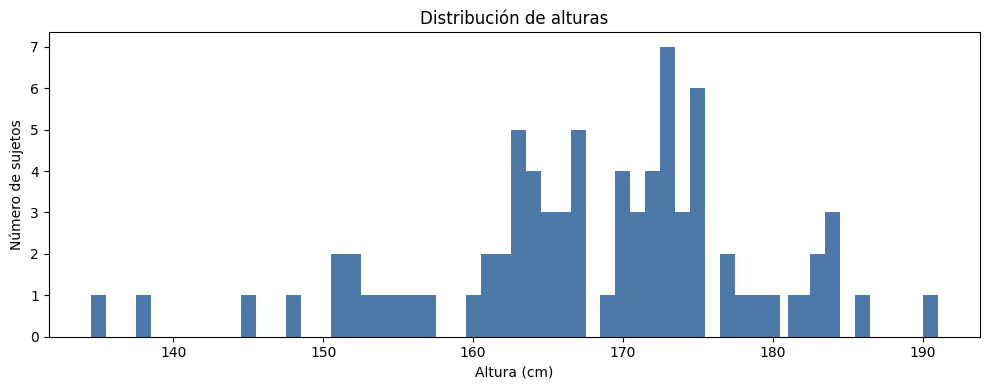

In [33]:
height_df = duckdb.query(
    """
    SELECT height_cm AS altura, COUNT(*) AS n_subjects
    FROM train_demographics_lf
    GROUP BY height_cm
    ORDER BY altura
    """
).pl()

plt.figure(figsize=(10, 4))
plt.bar(height_df["altura"], height_df["n_subjects"], color="#4C78A8", width=1.0)
plt.xlabel("Altura (cm)")
plt.ylabel("Número de sujetos")
plt.title("Distribución de alturas")
plt.tight_layout()
plt.show()

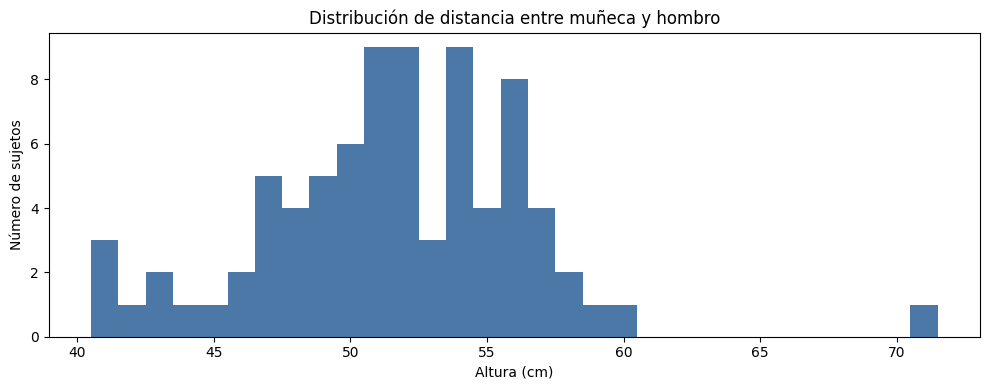

In [34]:
height_df = duckdb.query(
    """
    SELECT shoulder_to_wrist_cm AS altura, COUNT(*) AS n_subjects
    FROM train_demographics_lf
    GROUP BY shoulder_to_wrist_cm
    ORDER BY altura
    """
).pl()

plt.figure(figsize=(10, 4))
plt.bar(height_df["altura"], height_df["n_subjects"], color="#4C78A8", width=1.0)
plt.xlabel("Altura (cm)")
plt.ylabel("Número de sujetos")
plt.title("Distribución de distancia entre muñeca y hombro")
plt.tight_layout()
plt.show()

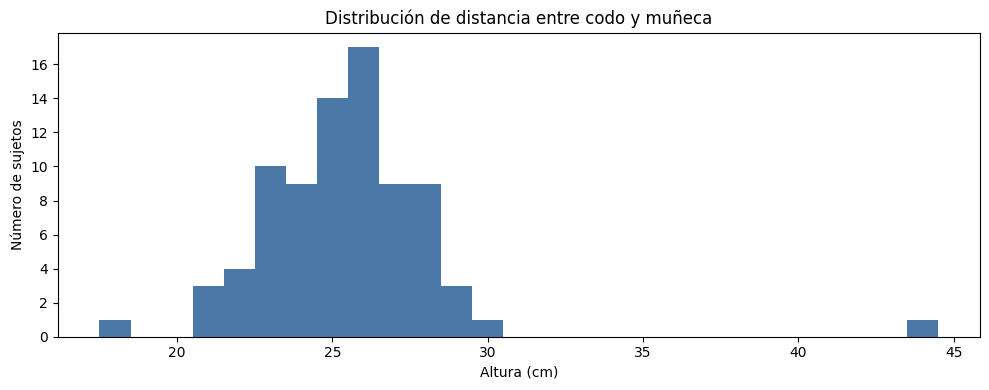

In [37]:
height_df = duckdb.query(
    """
    SELECT elbow_to_wrist_cm AS altura, COUNT(*) AS n_subjects
    FROM train_demographics_lf
    GROUP BY elbow_to_wrist_cm
    ORDER BY altura
    """
).pl()

plt.figure(figsize=(10, 4))
plt.bar(height_df["altura"], height_df["n_subjects"], color="#4C78A8", width=1.0)
plt.xlabel("Altura (cm)")
plt.ylabel("Número de sujetos")
plt.title("Distribución de distancia entre codo y muñeca")
plt.tight_layout()
plt.show()

## Longitud de las secuencias

Las secuencias tienen longitud indeterminada y estas compuestas por 3 posibles fases, pausas, transición y gesto

In [ ]:

duckdb.query("""SELECT sequence_id, MAX(sequence_counter) as max_counter, MIN(sequence_counter) as min_counter
            FROM train_lf
            GROUP BY sequence_id
            ORDER BY max_counter DESC
            LIMIT 10 
             """).pl()    



sequence_id,max_counter,min_counter
str,i64,i64
"""SEQ_015261""",699,0
"""SEQ_014205""",670,0
"""SEQ_028188""",646,0
"""SEQ_060593""",629,0
"""SEQ_016031""",566,0
"""SEQ_013984""",428,0
"""SEQ_065478""",425,0
"""SEQ_002216""",397,0
"""SEQ_008179""",392,0


In [42]:

duckdb.query("""SELECT sequence_id, MAX(sequence_counter) as max_counter, MIN(sequence_counter) as min_counter
            FROM train_lf
            GROUP BY sequence_id
            ORDER BY max_counter ASC
            LIMIT 10 
             """).pl()    



sequence_id,max_counter,min_counter
str,i64,i64
"""SEQ_009199""",28,0
"""SEQ_032114""",33,0
"""SEQ_059162""",33,0
"""SEQ_022667""",33,0
"""SEQ_011271""",33,0
"""SEQ_017406""",34,0
"""SEQ_011728""",34,0
"""SEQ_038837""",35,0
"""SEQ_014439""",35,0


## Ver fases

In [8]:
duckdb.query("""SELECT DISTINCT phase
            FROM train_lf
             """).pl()

phase
str
"""Gesture"""
"""Transition"""


In [23]:
def print_basics_sequence(train_lf, sequence_id: str):    

    seq_data = (
        train_lf.filter(pl.col("sequence_id") == sequence_id)
        .sort("sequence_counter")
        .collect()
        .to_pandas()
    )

    signals = ["acc_x", "acc_y", "acc_z", "rot_w", "rot_x", "rot_y", "rot_z"]
    signals = [s for s in signals if s in seq_data.columns]

    # Definir colores para cada fase
    phase_colors = {"Transition": "#FFA500", "Gesture": "#1f77b4"}

    fig, axes = plt.subplots(len(signals), 1, figsize=(12, 3*len(signals)), sharex=True)
    if len(signals) == 1:
        axes = [axes]

    for idx, signal in enumerate(signals):
        ax = axes[idx]
        
        # Dibujar bandas de fondo según la fase
        phase_col = seq_data["phase"].values
        x_col = seq_data["sequence_counter"].values
        
        current_phase = phase_col[0]
        start_x = x_col[0]
        
        for i in range(1, len(seq_data)):
            if phase_col[i] != current_phase:
                ax.axvspan(start_x, x_col[i], alpha=0.2, color=phase_colors.get(current_phase, "#cccccc"))
                current_phase = phase_col[i]
                start_x = x_col[i]
        
        # Última banda
        ax.axvspan(start_x, x_col[-1], alpha=0.2, color=phase_colors.get(current_phase, "#cccccc"))
        
        # Graficar la señal
        ax.plot(seq_data["sequence_counter"], seq_data[signal], linewidth=1.5, color="#2c3e50")
        ax.set_ylabel(signal)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Sequence Counter")
    gesture = seq_data["gesture"].iloc[0] if "gesture" in seq_data.columns else "Unknown"
    fig.suptitle(f"{sequence_id} - Señales IMU por Phase, Gesture: {gesture}", fontsize=14, y=1.00)

    # Leyenda personalizada
    legend_elements = [Patch(facecolor=color, alpha=0.2, label=phase) 
                    for phase, color in phase_colors.items()]
    fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(0.98, 0.98))

    plt.tight_layout()
    plt.show()

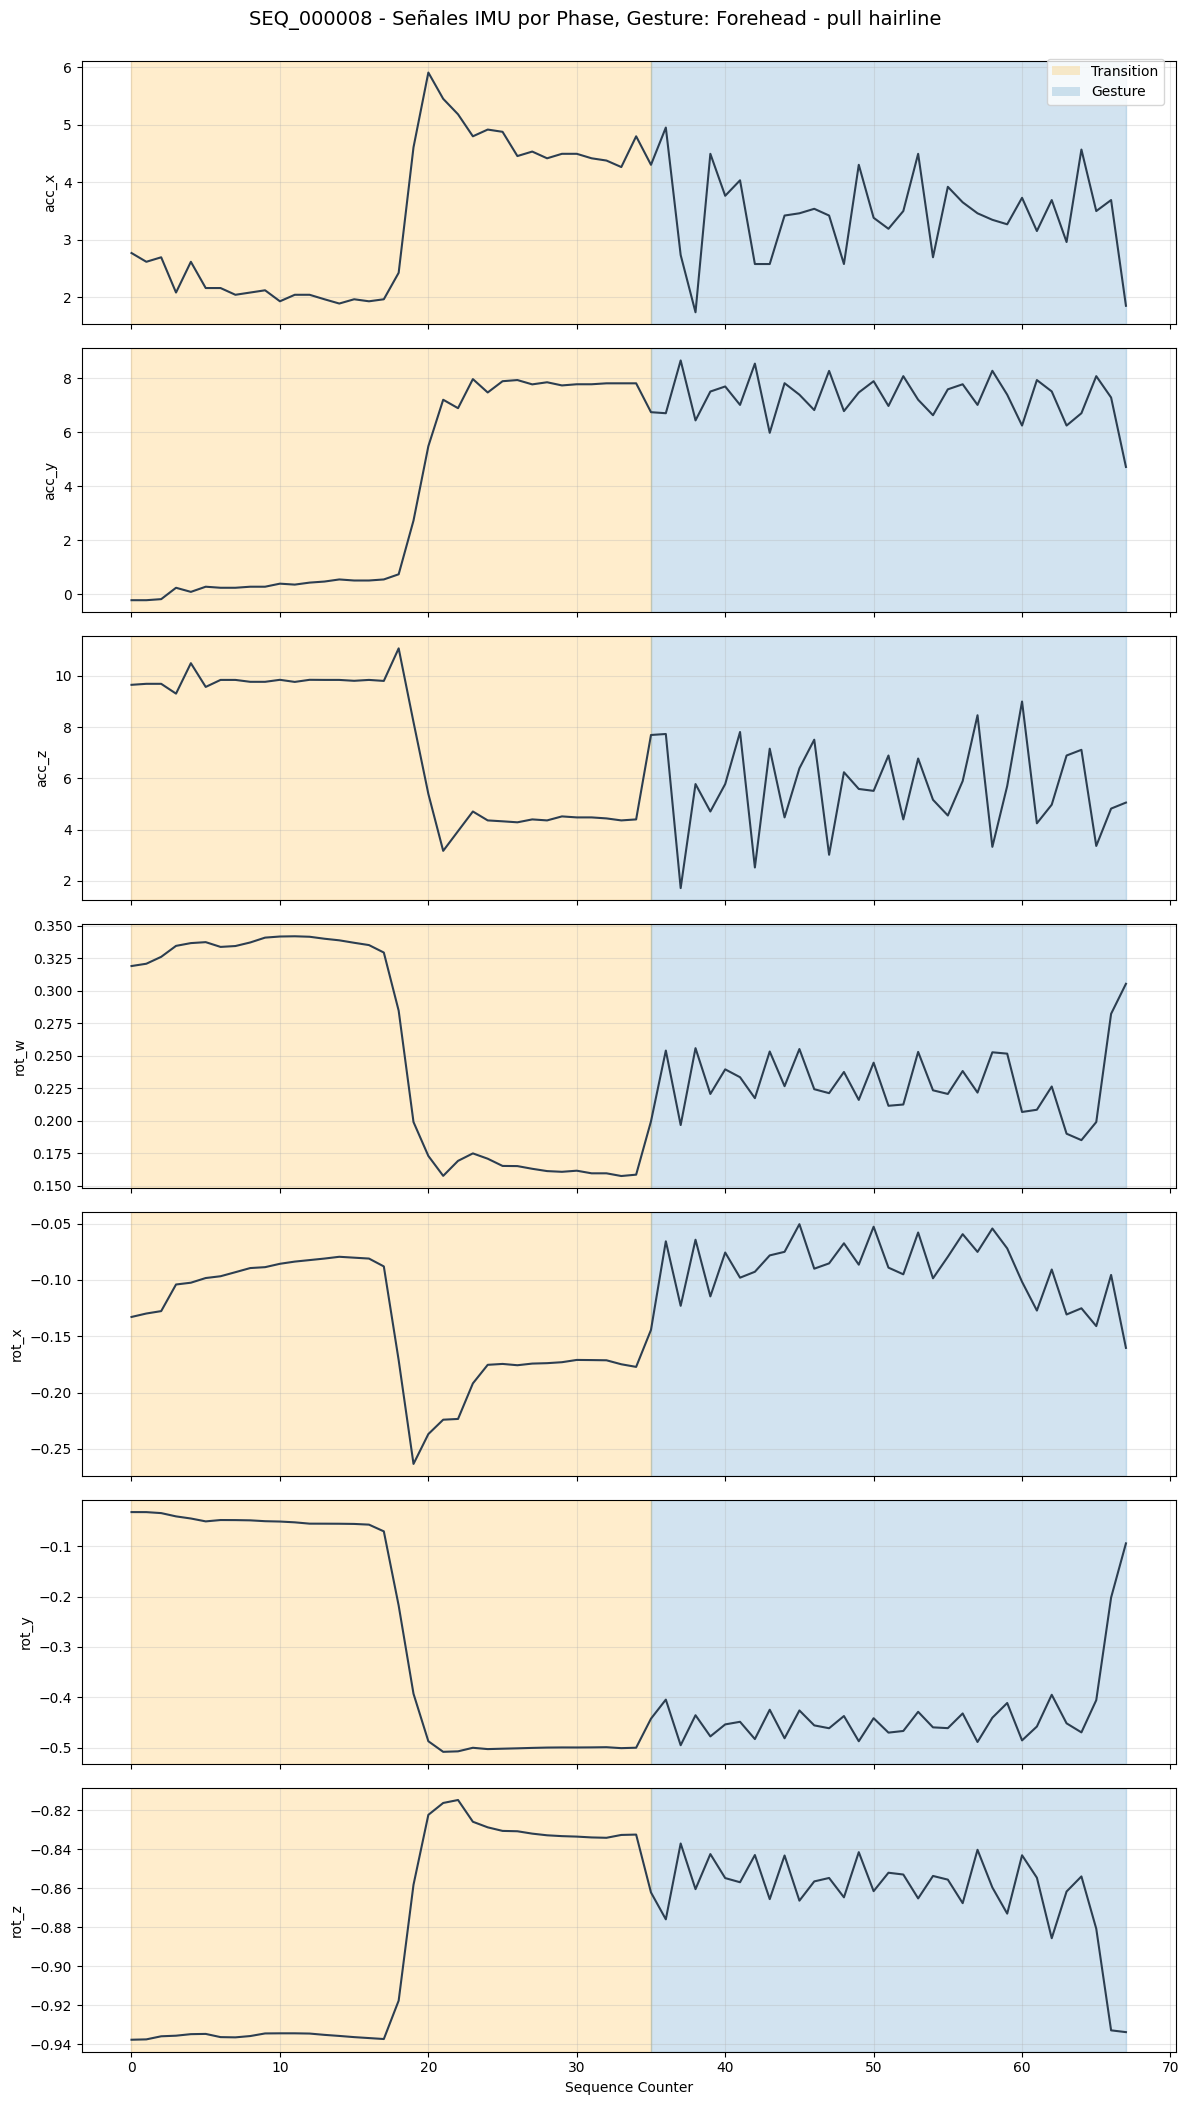

In [24]:
print_basics_sequence(train_lf, sequence_id="SEQ_000008")

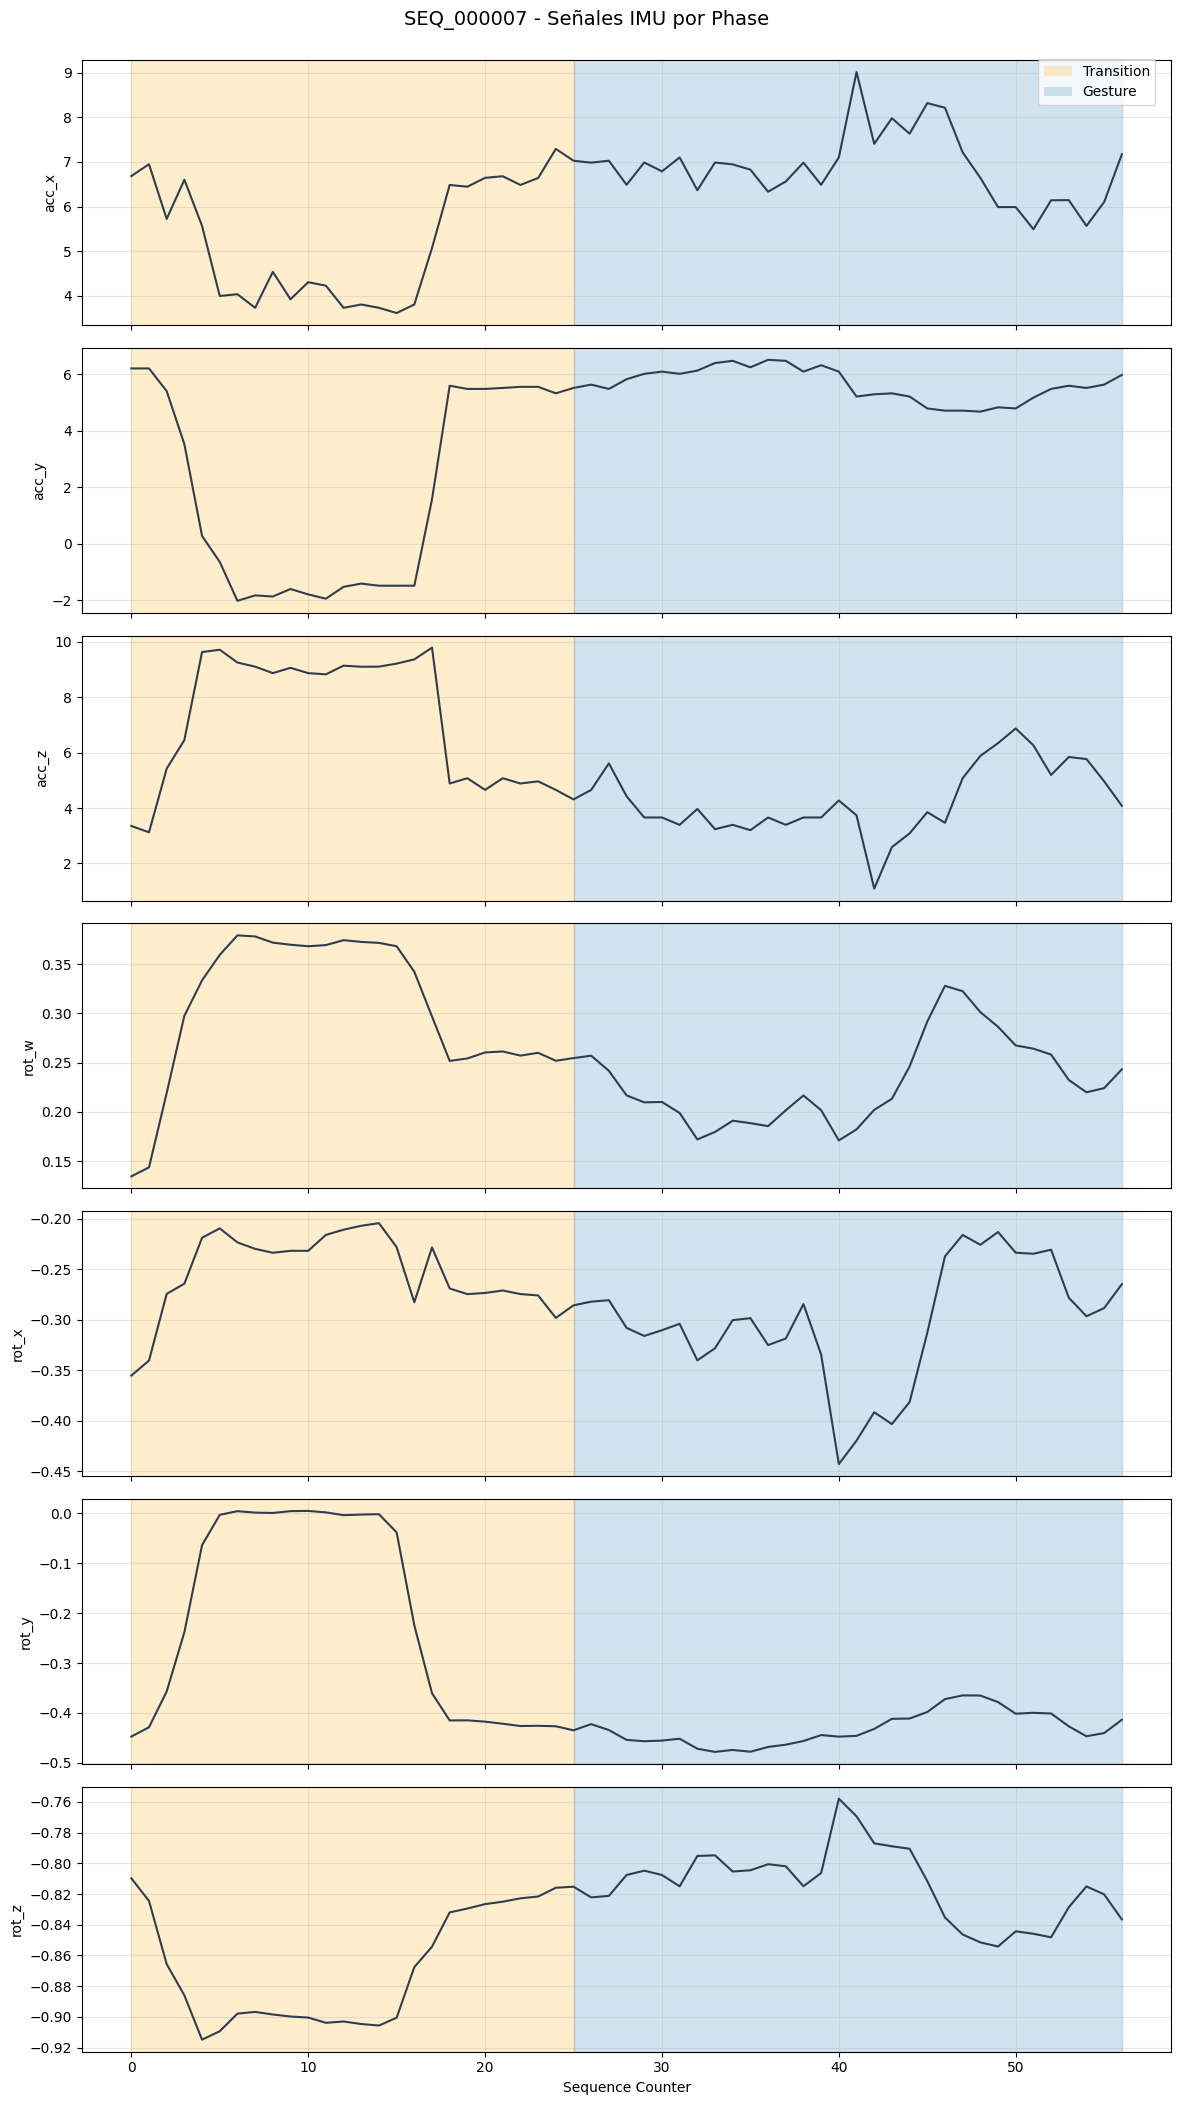

In [ ]:
print_basics_sequence(train_lf, sequence_id="SEQ_000008")